In [1]:
import numpy as np
import pandas as pd
from sklearn import svm
import heapq
from sklearn.feature_selection import SelectKBest, SelectPercentile, mutual_info_classif, chi2
from matplotlib import pyplot as plt

def read_data(data_path):
    data = pd.read_csv(data_path, header=None)
    X = np.array(data.iloc[1:].values.T[1:], dtype=float)
    y = list(data.iloc[0][1:])
    name_genes = data[0].values[1:]
    return X, y, name_genes
X, y, name_genes = read_data('GSE82009_max.csv')
print('number of genes after preprocessing is ', len(name_genes))

print(len(y))
print(len(X[0]))
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)
scaler = MinMaxScaler()
scaler = scaler.fit(X)
result = scaler.transform(X)
print(pd.DataFrame(result))

number of genes after preprocessing is  9141
50
9141
        0         1         2         3         4         5         6     \
0   0.245416  0.197226  1.000000  0.542364  1.000000  1.000000  0.350544   
1   0.686353  0.408283  0.407137  0.710773  0.601062  0.720497  0.567301   
2   0.412557  0.467126  0.583125  0.746133  0.852686  0.646091  0.782530   
3   0.346632  1.000000  0.000000  0.822800  0.332658  0.602172  0.248886   
4   0.785381  0.270714  0.552028  0.549997  0.604706  0.600118  0.215788   
5   0.579404  0.700079  0.699993  0.838694  0.498205  0.490624  0.694731   
6   0.399574  0.256748  0.501009  0.665531  0.502282  0.729922  0.339842   
7   0.970326  0.523234  0.780424  0.698718  0.727849  0.554038  0.355760   
8   0.300786  0.230360  0.605391  0.696068  0.608444  0.592420  0.503374   
9   0.493211  0.776201  0.418135  1.000000  0.229033  0.090786  0.228737   
10  0.523141  0.167976  0.751187  0.359158  0.604830  0.787732  1.000000   
11  0.485446  0.200161  0.535005  0

In [2]:
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
svc = SVC(kernel='linear', C=1)
# rf = RFC(max_depth =2, random_state=0)

selector1 = RFE(estimator = svc, n_features_to_select=150, step=2).fit(result,y)
print("RFE所选特征的掩码", selector1.support_)
print("RFE特征排除排序", selector1.ranking_)
df = pd.DataFrame(result)
X2 = selector1.get_support()
X3 = df.iloc[:,X2]
print(X3)
X4= X3.T
index_list = X4.index.tolist()
final_genes = name_genes[index_list]
print(len(final_genes))

RFE所选特征的掩码 [False False False ... False False False]
RFE特征排除排序 [ 183 2557 1863 ... 1160 3949  462]
        26        66        184       379       502       590       640   \
0   0.428049  0.254128  0.221042  0.103237  0.662470  0.728447  0.451933   
1   0.437043  0.185181  0.409615  0.299946  0.786562  0.567417  0.278783   
2   0.315997  0.573799  0.403601  0.905415  0.363364  0.672746  0.714147   
3   0.395904  0.490939  0.809572  0.370068  0.569396  0.569972  0.499097   
4   0.279834  0.257019  0.721640  0.347996  0.474460  0.449502  0.553944   
5   0.671680  0.597620  0.804642  0.636858  0.297923  0.146709  0.458150   
6   0.726146  0.248464  0.339366  0.150664  0.691469  0.499337  0.376683   
7   0.514803  0.403596  0.350871  0.751342  0.725493  0.572557  0.257720   
8   0.722545  0.262204  0.363866  1.000000  0.253613  0.271895  0.808579   
9   0.771704  0.858992  0.458189  0.637855  0.311689  0.450085  0.869901   
10  0.425525  0.543283  0.213616  0.415909  0.713000  0.735728  0

In [4]:
import numpy as np
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier as RFC
from matplotlib import pyplot as plt
from sklearn.model_selection import StratifiedKFold


class NSGA2():
    def __init__(self, all_genes, pop_size, max_generations, max_Ngen, features, labels):
        self.all_genes = all_genes
        self.pop_size = pop_size
        self.max_generations = max_generations
        self.max_Ngen = max_Ngen
        self.features = features
        self.labels = labels

    def fast_non_dominated_sort(self, all_values):
        values1, values2 = all_values[0], all_values[1]
#         print(len(values1), len(values2))
        S=[[] for i in range(0,len(values1))]
        front = [[]]
        n=[0 for i in range(0,len(values1))]
        rank = [0 for i in range(0, len(values1))]

        for p in range(0,len(values1)):
            S[p]=[]
            n[p]=0
            for q in range(0, len(values1)):
                if (values1[p] > values1[q] and values2[p] > values2[q]) or\
                        (values1[p] >= values1[q] and values2[p] > values2[q]) or\
                        (values1[p] > values1[q] and values2[p] >= values2[q]):
                    if q not in S[p]:
                        S[p].append(q)
                elif (values1[q] > values1[p] and values2[q] > values2[p]) or\
                        (values1[q] >= values1[p] and values2[q] > values2[p]) or\
                        (values1[q] > values1[p] and values2[q] >= values2[p]):
                    n[p] = n[p] + 1
            if n[p]==0:
                rank[p] = 0
                if p not in front[0]:
                    front[0].append(p)

        i = 0
        while(front[i] != []):
            Q=[]
            for p in front[i]:
                for q in S[p]:
                    n[q] =n[q] - 1
                    if( n[q]==0):
                        rank[q]=i+1
                        if q not in Q:
                            Q.append(q)
            i = i+1
            front.append(Q)

        del front[len(front)-1]
#         print(n)
        return front


#     def fast_non_dominated_sort(self, all_values):
#         N = len(all_values[0])
#         n = [0] * N
#         S = [[] for _ in range(N)]
#         pareto_rank = [0] * N
#         pareto_sorted = [[]]
#         for i in range(N):
#             for j in range(i+1, N):
#                 if (all_values[:, i] > all_values[:, j]).all() or \
#                    ((all_values[:, i] >= all_values[:, j]).all() and (all_values[:, i] != all_values[:, j]).any()):
#                     S[i].append(j)
#                     n[j] += 1
#                 elif (all_values[:, j] > all_values[:, i]).all() or \
#                      ((all_values[:, j] >= all_values[:, i]).all() and (all_values[:, j] != all_values[:, i]).any()):
#                     S[j].append(i)
#                     n[i] += 1
#             if n[i] == 0:
#                 pareto_sorted[0].append(i)
#         cur_rank = 0
#         while True:
#             sub_pareto = []
#             for i in range(N):
#                 if pareto_rank[i] == cur_rank:
#                     for j in S[i]:
#                         n[j] -= 1
#                         if n[j] == 0:
#                             pareto_rank[j] = cur_rank + 1
#                             sub_pareto.append(j)
#             if len(sub_pareto) > 0:
#                 pareto_sorted.append(sub_pareto)
#             else:
#                 break
#             cur_rank += 1
#         print(n)
# #         print(S)
#         return pareto_sorted

    def crowding_distance_sort(self, all_values, sub_pareto):
        N = len(sub_pareto)
        cd = [0] * N
        for values in all_values:
            sub_values = values[sub_pareto]
            max_value = np.max(sub_values)
            min_value = np.min(sub_values)
            sub_values_argsorted = np.argsort(sub_values)
            for i in range(1, N-1):
                cd[sub_values_argsorted[i]] += (sub_values[sub_values_argsorted[i+1]] - sub_values[sub_values_argsorted[i-1]]) / (max_value - min_value)
#         print(np.array(np.argsort(cd), dtype=int))
        return np.array(sub_pareto)[np.array(np.argsort(cd), dtype=int)]


    # def crossover(solution_a, solution_b):
    #     if np.random.rand(1) > 0.5:
    #         return mutation((solution_a + solution_b) / 2)
    #     else:
    #         return mutation((solution_a - solution_b) / 2)

    # def mutation(parent):
    #     M = 100
    #     u = np.random.rand(M)
    #     delta = ((2 * u) ** (1 / (1 + eta)) - 1) * (u < 0.5) + (1 - (2 * (1 - u)) ** (1 / (1 + eta))) * (u > 0.5)
    #     child = parent + delta
    #     child[child > x_max] = x_max[child > x_max]
    #     child[child < x_min] = x_min[child < x_min]
    #
    # def crossover():
    #     N = 10
    #     M = 100
    #     parent_1, parent_2 = np.random.choice(N, 2, replace=False)
    #     if np.random.rand() < 0.5:
    #         u = np.random.rand(M)
    #         gamma = (2 * u) ** (1 / (1 + eta)) * (u < 0.5) + (1 / (2 * (1 - u))) ** (1 / (1 + eta)) * (u > 0.5)
    #         child_1 = 0.5 * ((1 + gamma) * parent_1 + (1 - gamma) * parent_2)
    #         child_2 = 0.5 * ((1 - gamma) * parent_1 + (1 + gamma) * parent_2)
    #         child_1[child_1 > x_max] = x_max[child_1 > x_max]
    #         child_1[child_1 < x_min] = x_min[child_1 < x_min]
    #         child_2[child_2 > x_max] = x_max[child_2 > x_max]
    #         child_2[child_2 < x_min] = x_min[child_2 < x_min]


    def mutation(self, solution):
        list_solution = list(solution)[:]
        if len(list_solution) < self.max_Ngen and len(list_solution) > 1:
            if np.random.rand() < 1/3:
                list_solution.pop(np.random.randint(len(list_solution)))
            elif np.random.rand() < 2/3:
                list_solution[np.random.randint(len(list_solution))] = np.random.randint(len(self.all_genes))
            else:
                list_solution.append(np.random.randint(len(self.all_genes)))
        elif len(solution) < self.max_Ngen:
            if np.random.rand() < 0.5:
                list_solution.append(np.random.randint(len(self.all_genes)))
            else:
                list_solution[np.random.randint(len(list_solution))] = np.random.randint(len(self.all_genes))
        else:
            if np.random.rand() < 0.5:
                list_solution.pop(np.random.randint(len(list_solution)))
            else:
                list_solution[np.random.randint(len(list_solution))] = np.random.randint(len(self.all_genes))
#         print(list_solution)
        return np.array(list_solution)

    # def tournament_selection(candidates):
    #     double_N = len(candidates)
    #     k = double_N // 2

    def elitism(self, all_values, pareto_sorted):
        new_parents = []
        for sub_pareto in pareto_sorted:
#             print(sub_pareto)
            if len(sub_pareto) + len(new_parents) <= self.pop_size:
                new_parents.extend(sub_pareto)
            else:
                new_parents.extend(self.crowding_distance_sort(all_values, sub_pareto)[:self.pop_size-len(new_parents)])
        return new_parents

    def train(self, train_features, train_labels):
        model = svm.SVC()

#         print(train_features.shape)
        model.fit(train_features.reshape(train_features.shape[0], -1), train_labels.reshape(-1, 1))
        return model

    def test(self, test_features, test_labels, model):
        return model.score(test_features.reshape(test_features.shape[0], -1), test_labels.reshape(-1, 1))

    def function1(self, solution):
#         print(solution.shape)
        features = self.features[:, solution]
    
        accs = []
        cv = StratifiedKFold(n_splits=10, shuffle=False)
        for train_idx, test_idx in cv.split(features, self.labels):
            model = self.train(features[train_idx], self.labels[train_idx])
            accs.append(self.test(features[test_idx], self.labels[test_idx], model))
        return np.mean(accs)

    def function2(self, solution):
#         print(solution)
        num_genes = len(solution)
        return (len(self.all_genes) - num_genes) / len(self.all_genes)

    def execute(self):
        # 随机生成初始种群
        solutions = [np.random.choice(list(range(len(self.all_genes))), 1 + int(np.random.rand() * self.max_Ngen), False)\
                    for _ in range(self.pop_size)]
        solutions = [np.array([solution]) if isinstance(solution, int) else solution for solution in solutions]
#         print(solutions)
        for num_generation in range(self.max_generations):
            # 自适应度计算
#             print(len(solutions))
            solutions = [np.array([solution]) if isinstance(solution, int) else solution for solution in solutions]
            f1_values = [self.function1(solutions[i]) for i in range(0, self.pop_size)]
            f2_values = [self.function2(solutions[i]) for i in range(0, self.pop_size)]
            all_values = np.array([f1_values, f2_values])
            values = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
            probabilities = 0.1 + 0.9 * values / np.sum(values)
            probabilities = probabilities / np.sum(probabilities)
            # pareto等级
            non_dominated_sorted_solutions = self.fast_non_dominated_sort(all_values)
            
            accs = [nsga2.function1(solution) for solution in solutions]
            nums = [len(solution) for solution in solutions]
            scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
            print(f'the best one of generation {num_generation} is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
            

            new_solutions = solutions[:]  # P+Q
            for i in range(self.pop_size):
                new_solution = self.mutation(solutions[np.random.choice(list(range(len(solutions))), p=probabilities)])
#                 print(new_solution)
                new_solutions.append(new_solution)
            # 计算 P+Q种群的适应度
            f1_values = [self.function1(new_solutions[i]) for i in range(2 * self.pop_size)]
            f2_values = [self.function2(new_solutions[i]) for i in range(2 * self.pop_size)]
            all_values = np.array([f1_values, f2_values])
            # 非支配排序
            non_dominated_sorted_new_solutions = self.fast_non_dominated_sort(all_values)
#             print(non_dominated_sorted_new_solutions)
            # 得到下一代种群
#             print(len(new_solutions))
#             for i in self.elitism(all_values, non_dominated_sorted_new_solutions):
#                 print(i)
            solutions = [new_solutions[i] for i in self.elitism(all_values, non_dominated_sorted_new_solutions)]  # index
        return solutions





the best one of generation 0 is: accuracy is  0.9800000000000001 , num of genes is  10
the best one of generation 1 is: accuracy is  0.9800000000000001 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9800000000000001 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9800000000000001 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9800000000000001 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9800000000000001 , num of genes is  7
the best one of generation 6 is: accuracy is  0.9800000000000001 , num of genes is  5
the best one of generation 7 is: accuracy is  1.0 , num of genes is  9
the best one of generation 8 is: accuracy is  1.0 , num of genes is  9
the best one of generation 9 is: accuracy is  1.0 , num of genes is  6
the best one of generation 10 is: accuracy is  1.0 , num of genes is  6
the best one of generation 11 is: accuracy is  1.0 , num of genes is  6
the best one of generation 12 is: accura

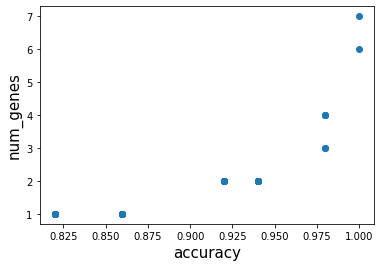

the best one is: accuracy is  1.0 , num of genes is  6
selected genes are:  ['AC007389.3' 'ACTN2' 'AADAC' 'ACE' 'ABCD2' 'ACRV1']
the best one of generation 0 is: accuracy is  0.96 , num of genes is  8
the best one of generation 1 is: accuracy is  1.0 , num of genes is  10
the best one of generation 2 is: accuracy is  1.0 , num of genes is  10
the best one of generation 3 is: accuracy is  1.0 , num of genes is  10
the best one of generation 4 is: accuracy is  1.0 , num of genes is  10
the best one of generation 5 is: accuracy is  1.0 , num of genes is  10
the best one of generation 6 is: accuracy is  1.0 , num of genes is  10
the best one of generation 7 is: accuracy is  1.0 , num of genes is  10
the best one of generation 8 is: accuracy is  1.0 , num of genes is  7
the best one of generation 9 is: accuracy is  1.0 , num of genes is  6
the best one of generation 10 is: accuracy is  1.0 , num of genes is  6
the best one of generation 11 is: accuracy is  1.0 , num of genes is  6
the best 

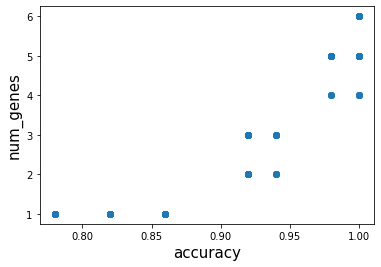

the best one is: accuracy is  1.0 , num of genes is  4
selected genes are:  ['ADAM20' 'ACADSB' 'ACTL6A' 'AATF']
the best one of generation 0 is: accuracy is  0.9600000000000002 , num of genes is  7
the best one of generation 1 is: accuracy is  0.9600000000000002 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9800000000000001 , num of genes is  8
the best one of generation 3 is: accuracy is  1.0 , num of genes is  7
the best one of generation 4 is: accuracy is  1.0 , num of genes is  7
the best one of generation 5 is: accuracy is  1.0 , num of genes is  7
the best one of generation 6 is: accuracy is  1.0 , num of genes is  7
the best one of generation 7 is: accuracy is  1.0 , num of genes is  7
the best one of generation 8 is: accuracy is  1.0 , num of genes is  7
the best one of generation 9 is: accuracy is  1.0 , num of genes is  7
the best one of generation 10 is: accuracy is  1.0 , num of genes is  7
the best one of generation 11 is: accuracy is  1.0 , num of g

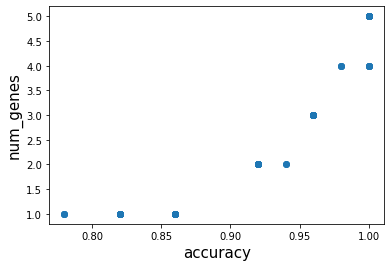

the best one is: accuracy is  1.0 , num of genes is  4
selected genes are:  ['ACOX1' 'ACADS' 'ACE' 'ABCC9']
the best one of generation 0 is: accuracy is  0.96 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9800000000000001 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9800000000000001 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9800000000000001 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9800000000000001 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9800000000000001 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9800000000000001 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9800000000000001 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9800000000000001 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9800000000000001 , num of genes is  4
the best one of generation 10 is: accuracy is 

In [ ]:
import warnings
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings("ignore")
# X3 = X3.values
i = 0
Glio_10 = {}
Glio_10_ngen = {}
while i < 25:
    nsga2 = NSGA2(all_genes=final_genes, pop_size=160, max_generations=25, max_Ngen=10,features=X3, labels=np.array(y))
    solutions = nsga2.execute()
    
    accs = [nsga2.function1(solution) for solution in solutions]
    nums = [len(solution) for solution in solutions]
    plt.xlabel('accuracy', fontsize=15)
    plt.ylabel('num_genes', fontsize=15)
    plt.scatter(accs, nums)
    plt.show()
    f1_values = [nsga2.function1(solution) for solution in solutions]
    f2_values = [nsga2.function2(solution) for solution in solutions]
    scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
    print('the best one is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
    print('selected genes are: ', name_genes[solutions[np.argmax(scores)]])
    Glio_10[i]=accs[np.argmax(scores)]
    Glio_10_ngen[i]=nums[np.argmax(scores)]
    i = i +1
print(Glio_10)
print(Glio_10_ngen)

In [ ]:
import warnings
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings("ignore")
# X3 = X3.values
i = 0
Glio_5 = {}
Glio_5_ngen = {}
while i < 25:
    nsga2 = NSGA2(all_genes=final_genes, pop_size=160, max_generations=25, max_Ngen=5,features=X3, labels=np.array(y))
    solutions = nsga2.execute()
    
    accs = [nsga2.function1(solution) for solution in solutions]
    nums = [len(solution) for solution in solutions]
    plt.xlabel('accuracy', fontsize=15)
    plt.ylabel('num_genes', fontsize=15)
    plt.scatter(accs, nums)
    plt.show()
    f1_values = [nsga2.function1(solution) for solution in solutions]
    f2_values = [nsga2.function2(solution) for solution in solutions]
    scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
    print('the best one is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
    print('selected genes are: ', name_genes[solutions[np.argmax(scores)]])
    Glio_10[i]=accs[np.argmax(scores)]
    Glio_10_ngen[i]=nums[np.argmax(scores)]
    i = i +1
print(Glio_5)
print(Glio_5_ngen)

In [ ]:
import warnings
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings("ignore")
# X3 = X3.values
i = 0
Glio_15 = {}
Glio_15_ngen = {}
while i < 25:
    nsga2 = NSGA2(all_genes=final_genes, pop_size=160, max_generations=25, max_Ngen=15,features=X3, labels=np.array(y))
    solutions = nsga2.execute()
    
    accs = [nsga2.function1(solution) for solution in solutions]
    nums = [len(solution) for solution in solutions]
    plt.xlabel('accuracy', fontsize=15)
    plt.ylabel('num_genes', fontsize=15)
    plt.scatter(accs, nums)
    plt.show()
    f1_values = [nsga2.function1(solution) for solution in solutions]
    f2_values = [nsga2.function2(solution) for solution in solutions]
    scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
    print('the best one is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
    print('selected genes are: ', name_genes[solutions[np.argmax(scores)]])
    Glio_10[i]=accs[np.argmax(scores)]
    Glio_10_ngen[i]=nums[np.argmax(scores)]
    i = i +1
print(Glio_15)
print(Glio_15_ngen)